In [30]:
import roiadjust as ra
from pystackreg import StackReg
import matplotlib.pyplot as plt
import numpy as np

g:\Programme\Anaconda\envs\roi\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [34]:
# Video der Kalium Stimulation als .avi File im angegebenen Pfad in sortierter Reihenfolge laden
video_kalium, video_kalium_path = ra.load_file(r"E:\Calcium Imaging\Paper NA3\Spontan vs PGPC\Spontan\2022_08_16\2022_08_16_mouse_DRG_d4_K+_2")

# Video der Spontanaktivität laden
video_sp, video_sp_path = ra.load_file(r"E:\Calcium Imaging\Paper NA3\Spontan vs PGPC\Spontan\2022_08_16\2022_08_16_mouse_DRG_d4_spontan_2")

# FPS der Videos angeben
video_fps = 10

Länge des Videos: 3998 Frames
Länge des Videos: 3000 Frames


In [ ]:


# Intensität des geladenen, aligned Videos entlang der Achse 0 (=Frames) mitteln 
# -> ergibt ein gemitteltes Bild aller Pixel-Helligkeiten über die Länge des Videos
video_kalium_mean = video_kalium_cor.mean(axis=0)
video_sp_mean = video_sp_cor.mean(axis=0)

In [36]:
# Berechnung der Transformation zwischen K+ und Spontanvideo mean
sr = StackReg(StackReg.RIGID_BODY)
tmat = sr.register(video_kalium_mean, video_sp_mean)

# Aligning des gesamten Spontanvideos
video_sp_aligned = np.array([
    sr.transform(frame, tmat=tmat)
    for frame in video_sp_cor
])

In [39]:
def save_video_uncompressed(video, video_path, video_fps, export=bool):

    height, width = video.shape[1], video.shape[2]

    fourcc = cv2.VideoWriter_fourcc(*'Y800')  # uncompressed grayscale
    
    export_path = video_path.parent / (video_path.stem + "_adjusted.avi")

    if export==True:
        writer = cv2.VideoWriter(
            str(export_path),
            fourcc,
            video_fps,
            (width, height),
            isColor=False
        )

    for frame in video:
        writer.write(frame)

    writer.release()
    return

In [40]:
# Exportieren des aligned Videos
aligned_sp_uint8 = np.clip(video_sp_aligned, 0, 255).astype(np.uint8)
save_video_uncompressed(aligned_sp_uint8, video_sp_path, video_fps, export=True)

In [43]:
# Hervorsagen der Neurone mit 70% Wahrscheinlichkeit (prob) im adjustierten K+ Video und exportieren nach video_path
labels, polygons = ra.predict_neurons(video_kalium_mean, video_kalium_path, export=False, prob=0.6)

# ROIs auf K+ Aktivität analysieren, mit Hochpassfilter cutoff und Peak Prominence prom
ra.analyze_roi_traces(video_kalium_cor, video_kalium_mean, video_kalium_path, labels, video_fps, show_graphs=False, export=True, prom=2, cutoff=0.2)

Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
24 counted, positive ROIs
Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(260, 348), dtype=int32),
 {'coord': array([[[108.       , 109.080475 , 109.986824 , ..., 104.8442   ,
           106.05033  , 106.90748  ],
          [ 31.612104 ,  31.43192  ,  30.796616 , ...,  30.722992 ,
            30.706924 ,  31.49248  ]],
  
         [[ 62.       ,  63.036797 ,  63.843864 , ...,  58.66855  ,
            59.95648  ,  60.897377 ],
          [ 15.611073 ,  15.2123375,  14.451479 , ...,  14.985872 ,
            14.9334955,  15.543263 ]],
  
         [[246.       , 247.30127  , 248.546    , ..., 242.05763  ,
           243.19615  , 244.62479  ],
          [ 59.07978  ,  58.54192  ,  58.146614 , ...,  57.900166 ,
            58.76909  ,  58.913666 ]],
  
         ...,
  
         [[248.       , 248.83997  , 249.58632  , ..., 246.32033  ,
           246

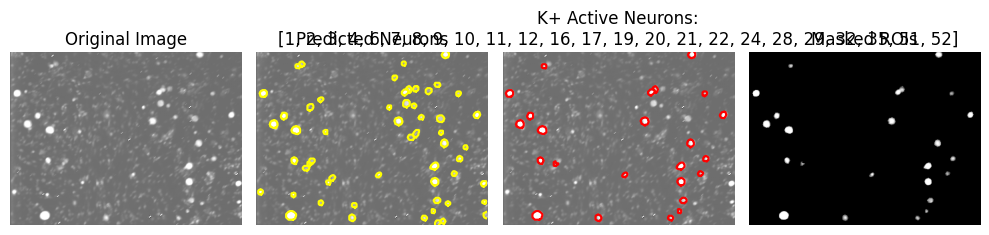

In [42]:
# Übersichtsplot der predicted und active Neurons + ROI Maske
ra.compare_roi_selection(video_kalium_mean, labels)